# Conway's Game of Life Cellular Automata

Conway's Game of Life is a zero-player cellular automaton game defined on a 2D grid. Each cell is either alive (1) or dead (0). In each generation, cells transition based on standard rules:
1. **Underpopulation**: A live cell with < 2 live neighbors dies.
2. **Survival**: A live cell with 2 or 3 live neighbors lives.
3. **Overpopulation**: A live cell with > 3 live neighbors dies.
4. **Reproduction**: A dead cell with exactly 3 live neighbors becomes alive.

This project simulates cell populations over generations starting from glider configurations.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define Game of life simulation grid helper
def update_grid(grid):
    new_grid = grid.copy()
    N = grid.shape[0]
    
    for i in range(N):
        for j in range(N):
            # Compute 8-neighbor sum with periodic (toroidal) boundary conditions
            neighbors_sum = int(
                grid[(i-1)%N, (j-1)%N] + grid[(i-1)%N, j] + grid[(i-1)%N, (j+1)%N] +
                grid[i, (j-1)%N]                         + grid[i, (j+1)%N] +
                grid[(i+1)%N, (j-1)%N] + grid[(i+1)%N, j] + grid[(i+1)%N, (j+1)%N]
            )
            
            # Apply Conway's rules
            if grid[i, j] == 1:
                if neighbors_sum < 2 or neighbors_sum > 3:
                    new_grid[i, j] = 0
            else:
                if neighbors_sum == 3:
                    new_grid[i, j] = 1
                    
    return new_grid

# Initialize a 50x50 grid with zeros
N = 50
grid = np.zeros((N, N), dtype=int)

# Insert a "Glider" structural configuration (a pattern that moves diagonally)
glider = np.array([
    [0, 1, 0],
    [0, 0, 1],
    [1, 1, 1]
])
grid[2:5, 2:5] = glider

# Insert a "Blinker" oscillator configuration
grid[10:13, 20] = 1

# Insert some random noise blocks to make the simulation organic and fun
np.random.seed(42)
random_cells = np.random.choice([0, 1], size=(20, 20), p=[0.85, 0.15])
grid[20:40, 20:40] = random_cells



## Generations Progression

We run the simulation forward. We store the state of the grid at Generation 0, 10, 20, and 50 to examine how the structures migrate, collide, and stabilize.



In [2]:
generations_to_save = [0, 10, 20, 50]
saved_states = {}

current_grid = grid.copy()
for gen in range(51):
    if gen in generations_to_save:
        saved_states[gen] = current_grid.copy()
    current_grid = update_grid(current_grid)

print("Saved grid states count:", len(saved_states))



Saved grid states count: 4


## Cellular Automata Grid Progression Plot

We arrange the saved grid states side-by-side in a 2x2 subplot grid, visualizing the evolution of cellular populations over time.



<cell>:15: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



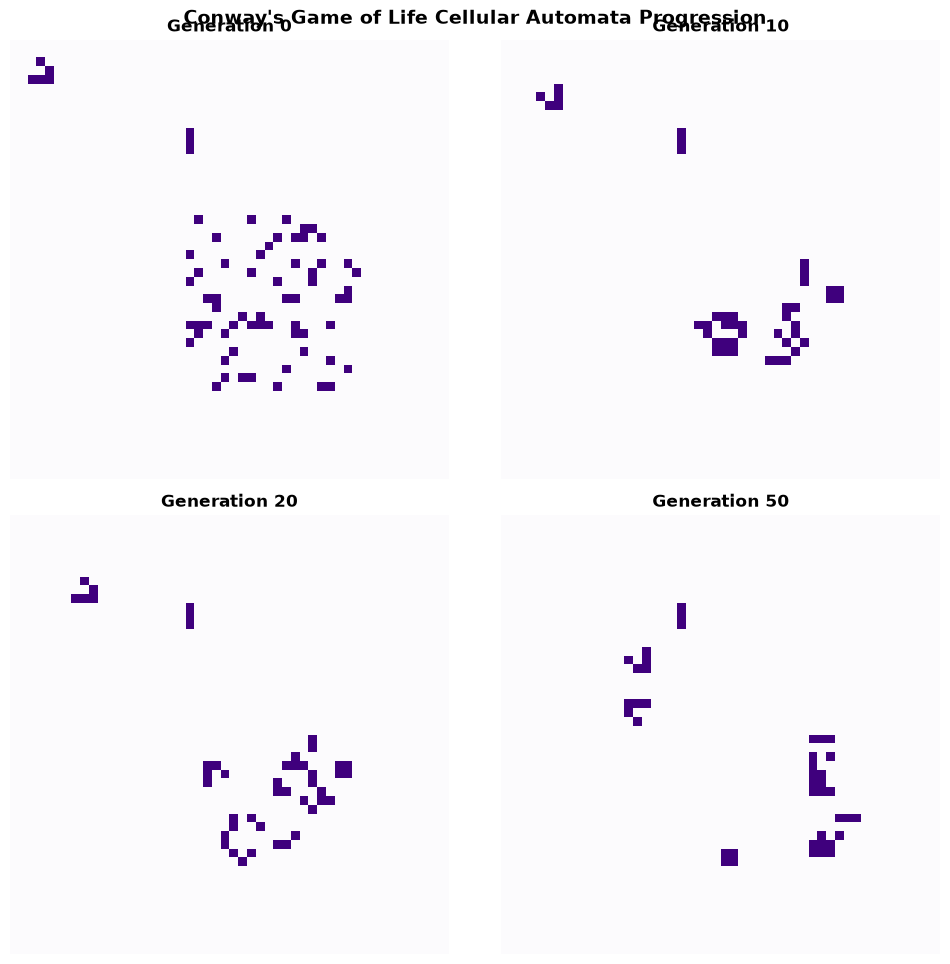

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes_flat = axes.flatten()

# Color palettes: 'binary' or 'Purples' look clean
cmap_color = 'Purples'

for idx, gen in enumerate(generations_to_save):
    ax = axes_flat[idx]
    ax.imshow(saved_states[gen], cmap=cmap_color, interpolation='nearest')
    ax.set_title(f"Generation {gen}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Conway's Game of Life Cellular Automata Progression", fontsize=14, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()
